# Deep Neural Network PII Classifier — BGE + Patterns + Column Semantics + Softmax

Pipeline:

`Column → BGE semantic embedding + value patterns + column-name evidence + PK/FK metadata → feature fusion → deep neural network → Softmax PII type`

This notebook keeps the existing feature-engineering pipeline but replaces the Logistic Regression classifier with a feed-forward deep neural network. The final output layer uses **Softmax only**, producing a probability distribution across all PII classes.

Hidden layers use **ReLU** activations with mild L2 regularization, Batch Normalization, and Dropout for stable training and regularization.

## 1. Install dependencies

Run this cell once inside the `cognienv` environment.

In [32]:
%pip install -U sentence-transformers scikit-learn pandas numpy matplotlib joblib tensorflow


Note: you may need to restart the kernel to use updated packages.


In [33]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
TEST_SIZE = 0.20
BATCH_SIZE = 32
MODEL_NAME = 'BAAI/bge-small-en-v1.5'

SCRIPT_DIR = Path.cwd()
candidate_dataset_paths = [
    SCRIPT_DIR / 'dataset' / 'pii_training_dataset_expanded.csv',
    SCRIPT_DIR / 'ml' / 'dataset' / 'pii_training_dataset_expanded.csv',
    SCRIPT_DIR / 'PII-Detection-Data-Masking' / 'ml' / 'dataset' / 'pii_training_dataset_expanded.csv',
    SCRIPT_DIR / 'pii_training_dataset_expanded.csv',
    Path('/home/immortalzz/cogniPII/PII-Detection-Data-Masking/ml/dataset/pii_training_dataset_expanded.csv'),
]

DATASET_PATH = None
for p in candidate_dataset_paths:
    if p.exists():
        DATASET_PATH = p
        break

if DATASET_PATH is None:
    raise FileNotFoundError('Could not locate pii_training_dataset_expanded.csv in any expected location.')

MODEL_DIR = DATASET_PATH.parent.parent / 'pii_classifier'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset:', DATASET_PATH)
print('BGE model:', MODEL_NAME)
print('Export directory:', MODEL_DIR)


Dataset: /home/immortalzz/cogniPII/PII-Detection-Data-Masking/ml/dataset/pii_training_dataset_expanded.csv
BGE model: BAAI/bge-small-en-v1.5
Export directory: /home/immortalzz/cogniPII/PII-Detection-Data-Masking/ml/pii_classifier


## 2. Load the expanded dataset

The expanded dataset contains 949 clean records with balanced representation across the 13 PII classes, including many hard-negative NON_PII examples such as `account_type`.


In [34]:
df = pd.read_csv(DATASET_PATH)

required_columns = {
    'domain', 'table_name', 'table_type', 'column_name',
    'data_type', 'is_primary_key', 'is_foreign_key',
    'sample_values', 'label'
}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f'Missing columns: {sorted(missing)}')

df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(str).str.strip()

print('Shape:', df.shape)
print('\nClass distribution:')
display(df['label'].value_counts().sort_index())


Shape: (4619, 9)

Class distribution:


label
ADDRESS                     300
BANK_ACCOUNT_NUMBER         224
DATE_OF_BIRTH               235
DEMOGRAPHIC_INFORMATION     270
DIRECT_IDENTIFIER           393
EMAIL                       270
FINANCIAL_INFORMATION       365
HEALTH_INFORMATION          266
LOCATION                    337
MEDICAL_RECORD_NUMBER       202
NON_PII                    1064
PERSON_NAME                 406
PHONE                       287
Name: count, dtype: int64

## 3. Build semantic text for BGE

The text combines the column name, table context, datatype, key metadata and representative values.

In [35]:
def clean_value(value):
    if pd.isna(value):
        return 'NULL'
    return str(value).strip()


def build_semantic_text(row):
    return (
        f"Domain: {clean_value(row['domain'])}. "
        f"Table: {clean_value(row['table_name'])}. "
        f"Table type: {clean_value(row['table_type'])}. "
        f"Column: {clean_value(row['column_name'])}. "
        f"Data type: {clean_value(row['data_type'])}. "
        f"Sample values: {clean_value(row['sample_values'])}."
    )

texts = [build_semantic_text(row) for _, row in df.iterrows()]
print(texts[0])


Domain: Medical. Table: patient_records. Table type: FACT. Column: net_worth. Data type: numeric. Sample values: 640000|850000|1200000.


## 4. Pattern / profiling feature extraction

The pattern layer is intentionally separate from BGE. It measures how strongly the actual sample values exhibit recognizable structures.

Features include:
- email match ratio
- Indian phone match ratio
- date match ratio
- credit-card-like match ratio
- bank-account-like numeric match ratio
- medical-record-like identifier ratio
- numeric/alphabetic/alphanumeric ratios
- null ratio
- uniqueness ratio
- average/min/max value length
- primary-key and foreign-key indicators


In [36]:
EMAIL_RE = re.compile(r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$')
PHONE_RE = re.compile(r'^(?:\+91[- ]?|0)?[6-9]\d{9}$')
DATE_RE = re.compile(r'^(?:\d{4}[-/]\d{1,2}[-/]\d{1,2}|\d{1,2}[-/]\d{1,2}[-/]\d{4})$')
CREDIT_CARD_RE = re.compile(r'^(?:\d[ -]?){13,19}$')
BANK_ACCOUNT_RE = re.compile(r'^\d{8,18}$')
MEDICAL_RECORD_RE = re.compile(r'^(?:MRN[-_ ]?)?[A-Za-z0-9]{5,20}$', re.I)
ALPHA_RE = re.compile(r'^[A-Za-z .\-\']+$')
NUMERIC_RE = re.compile(r'^[-+]?\d+(?:\.\d+)?$')
ALPHANUMERIC_RE = re.compile(r'^[A-Za-z0-9]+$')


def split_sample_values(value):
    if pd.isna(value):
        return []

    raw = str(value).strip()
    if not raw or raw.upper() == 'NULL':
        return []

    # The current dataset uses | as the sample-value separator.
    return [x.strip() for x in raw.split('|') if x.strip()]


def safe_ratio(matches, total):
    return matches / total if total else 0.0


def profile_samples(sample_values):
    values = split_sample_values(sample_values)
    n = len(values)

    if n == 0:
        return np.zeros(18, dtype=np.float32)

    lengths = np.array([len(v) for v in values], dtype=np.float32)

    email_ratio = safe_ratio(sum(bool(EMAIL_RE.fullmatch(v)) for v in values), n)
    phone_ratio = safe_ratio(sum(bool(PHONE_RE.fullmatch(v)) for v in values), n)
    date_ratio = safe_ratio(sum(bool(DATE_RE.fullmatch(v)) for v in values), n)
    credit_card_ratio = safe_ratio(sum(bool(CREDIT_CARD_RE.fullmatch(v.replace(' ', ''))) for v in values), n)
    bank_account_ratio = safe_ratio(sum(bool(BANK_ACCOUNT_RE.fullmatch(v)) for v in values), n)
    medical_record_ratio = safe_ratio(sum(bool(MEDICAL_RECORD_RE.fullmatch(v)) for v in values), n)
    numeric_ratio = safe_ratio(sum(bool(NUMERIC_RE.fullmatch(v)) for v in values), n)
    alphabetic_ratio = safe_ratio(sum(bool(ALPHA_RE.fullmatch(v)) for v in values), n)
    alphanumeric_ratio = safe_ratio(sum(bool(ALPHANUMERIC_RE.fullmatch(v)) for v in values), n)

    unique_ratio = len(set(v.lower() for v in values)) / n

    return np.array([
        email_ratio,
        phone_ratio,
        date_ratio,
        credit_card_ratio,
        bank_account_ratio,
        medical_record_ratio,
        numeric_ratio,
        alphabetic_ratio,
        alphanumeric_ratio,
        unique_ratio,
        float(lengths.mean()),
        float(lengths.min()),
        float(lengths.max()),
        float(n == 0),
        float(len(values)),
        float(np.std(lengths)),
        float(np.mean([len(v.split()) for v in values])),
        float(np.mean([any(c.isdigit() for c in v) for v in values])),
    ], dtype=np.float32)


pattern_features = np.vstack(
    [profile_samples(x) for x in df['sample_values']]
)

pattern_feature_names = [
    'email_match_ratio',
    'phone_match_ratio',
    'date_match_ratio',
    'credit_card_match_ratio',
    'bank_account_match_ratio',
    'medical_record_match_ratio',
    'numeric_ratio',
    'alphabetic_ratio',
    'alphanumeric_ratio',
    'unique_ratio',
    'avg_length',
    'min_length',
    'max_length',
    'null_or_empty',
    'sample_count',
    'length_std',
    'avg_word_count',
    'contains_digit_ratio',
]

pattern_df = pd.DataFrame(pattern_features, columns=pattern_feature_names)
display(pattern_df.head())


,email_match_ratio,phone_match_ratio,date_match_ratio,credit_card_match_ratio,bank_account_match_ratio,medical_record_match_ratio,numeric_ratio,alphabetic_ratio,alphanumeric_ratio,unique_ratio,avg_length,min_length,max_length,null_or_empty,sample_count,length_std,avg_word_count,contains_digit_ratio
0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,0.0,1.000000,1.000000,6.333333,6.0,7.0,0.0,3.0,0.471405,1.000000,1.0
1,0.0,0.0,0.0,0.0,0.0,1.000000,0.0,1.0,1.000000,0.666667,6.333333,6.0,7.0,0.0,3.0,0.471405,1.000000,0.0
2,0.0,0.0,0.0,0.0,1.0,1.000000,1.0,0.0,1.000000,1.000000,12.000000,12.0,12.0,0.0,3.0,0.000000,1.000000,1.0
3,0.0,0.0,0.0,0.0,0.0,0.333333,0.0,1.0,0.333333,1.000000,11.333333,9.0,15.0,0.0,3.0,2.624669,1.333333,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,0.000000,1.000000,7.333333,7.0,8.0,0.0,3.0,0.471405,1.000000,1.0


## 5. Generate BGE embeddings

In [37]:
print('Loading:', MODEL_NAME)
bge = SentenceTransformer(MODEL_NAME)

embeddings = bge.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print('Embedding shape:', embeddings.shape)


Loading: BAAI/bge-small-en-v1.5


Batches: 100%|██████████| 145/145 [00:04<00:00, 30.25it/s]

Embedding shape: (4619, 384)


## 6. Add metadata features and create the hybrid feature vector

In [38]:
def binary_feature(value):
    return int(str(value).strip().lower() in {'true', '1', 'yes', 'y'})

# Explicit lexical evidence from the column name.
# These features are intentionally category-oriented so account_type can be
# learned as a hard negative rather than being treated as an account number.
COLUMN_KEYWORDS = [
    'email', 'phone', 'address', 'name', 'dob', 'birth', 'date',
    'account_number', 'account_no', 'account_num', 'bank_account',
    'account', 'medical', 'record', 'location', 'blood', 'gender',
    'balance', 'salary', 'diagnosis', 'doctor', 'campaign', 'customer',
    'student', 'patient', 'employee', 'member', 'id', 'key',
    'amount', 'income', 'credit', 'debit', 'transaction',
]


def column_name_features(column_name):
    name = str(column_name).lower().replace('-', '_')
    return np.array([float(k in name) for k in COLUMN_KEYWORDS], dtype=np.float32)


column_name_features_matrix = np.vstack([
    column_name_features(x) for x in df['column_name']
])

metadata_features = np.array([
    [binary_feature(row['is_primary_key']), binary_feature(row['is_foreign_key'])]
    for _, row in df.iterrows()
], dtype=np.float32)

extra_features = np.hstack([
    pattern_features,
    column_name_features_matrix,
    metadata_features,
]).astype(np.float32)

extra_feature_names = (
    pattern_feature_names
    + [f'column_keyword__{k}' for k in COLUMN_KEYWORDS]
    + ['is_primary_key', 'is_foreign_key']
)

print('BGE features              :', embeddings.shape[1])
print('Pattern features          :', pattern_features.shape[1])
print('Column-name features     :', column_name_features_matrix.shape[1])
print('PK/FK metadata features  :', metadata_features.shape[1])
print('Extra features            :', extra_features.shape[1])
print('Full feature vector       :', embeddings.shape[1] + extra_features.shape[1])


BGE features              : 384
Pattern features          : 18
Column-name features     : 34
PK/FK metadata features  : 2
Extra features            : 54
Full feature vector       : 438


## 7. Inspect pattern signals

Before training, inspect whether the patterns are actually detecting the structures we expect.

In [39]:
inspection = df[['domain', 'table_name', 'column_name', 'label']].copy()
inspection = pd.concat([inspection.reset_index(drop=True), pattern_df], axis=1)

display(
    inspection[
        [
            'domain', 'table_name', 'column_name', 'label',
            'email_match_ratio', 'phone_match_ratio',
            'date_match_ratio', 'bank_account_match_ratio',
            'medical_record_match_ratio', 'numeric_ratio'
        ]
    ].head(25)
)


,domain,table_name,column_name,label,email_match_ratio,phone_match_ratio,date_match_ratio,bank_account_match_ratio,medical_record_match_ratio,numeric_ratio
0,Medical,patient_records,net_worth,FINANCIAL_INFORMATION,0.0,0.0,0.0,0.0,1.000000,1.0
1,Healthcare,health_records,nationality,DEMOGRAPHIC_INFORMATION,0.0,0.0,0.0,0.0,1.000000,0.0
2,Finance,financial_records,beneficiary_account,BANK_ACCOUNT_NUMBER,0.0,0.0,0.0,1.0,1.000000,1.0
3,Medical,fact_admission,clinical_status,HEALTH_INFORMATION,0.0,0.0,0.0,0.0,0.333333,0.0
4,Healthcare,health_records,transaction_amount,FINANCIAL_INFORMATION,0.0,0.0,0.0,0.0,0.000000,1.0
5,Banking,banking,account_type,NON_PII,0.0,0.0,0.0,0.0,1.000000,0.0
6,Marketing,dim_channel,channel_key,NON_PII,0.0,0.0,0.0,0.0,0.000000,1.0
7,Banking,dim_account,person_date_of_birth,DATE_OF_BIRTH,0.0,0.0,1.0,0.0,0.000000,0.0
8,Medical,patient_records,day,NON_PII,0.0,0.0,0.0,0.0,0.000000,1.0
9,Banking,customer_account,quantity,NON_PII,0.0,0.0,0.0,0.0,0.000000,1.0


## 8. Encode labels and make one stratified train/test split

The same indices will be used for evaluation so the results are directly comparable.

In [40]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train rows:', len(train_idx))
print('Test rows :', len(test_idx))
print('\nClasses:', list(label_encoder.classes_))


Train rows: 3695
Test rows : 924

Classes: ['ADDRESS', 'BANK_ACCOUNT_NUMBER', 'DATE_OF_BIRTH', 'DEMOGRAPHIC_INFORMATION', 'DIRECT_IDENTIFIER', 'EMAIL', 'FINANCIAL_INFORMATION', 'HEALTH_INFORMATION', 'LOCATION', 'MEDICAL_RECORD_NUMBER', 'NON_PII', 'PERSON_NAME', 'PHONE']


## 9. Train the Deep Neural Network classifier — Softmax output only

This version replaces the Logistic Regression classifier with a feed-forward deep neural network.

**Architecture:** normalized BGE embedding + engineered features → Dense(512, ReLU) → BatchNorm → Dropout → Dense(256, ReLU) → BatchNorm → Dropout → Dense(128, ReLU) → Dense(13, Softmax).

The **only output activation is Softmax**. ReLU is used in hidden layers for nonlinear feature learning. The final Softmax produces a probability distribution over all PII classes.

In [41]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# BGE embeddings are already normalized; engineered features are scaled separately.
extra_scaler = StandardScaler()
extra_train = extra_scaler.fit_transform(extra_features[train_idx]).astype(np.float32)
extra_test = extra_scaler.transform(extra_features[test_idx]).astype(np.float32)

X_train = np.hstack([embeddings[train_idx], extra_train]).astype(np.float32)
X_test = np.hstack([embeddings[test_idx], extra_test]).astype(np.float32)
y_train = y[train_idx].astype(np.int32)
y_test = y[test_idx].astype(np.int32)

# Stratified train/validation split ensures all 13 classes are proportionally represented in validation.
tr_sub_idx, val_sub_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
X_tr, X_val = X_train[tr_sub_idx], X_train[val_sub_idx]
y_tr, y_val = y_train[tr_sub_idx], y_train[val_sub_idx]

n_classes = len(label_encoder.classes_)
input_dim = X_train.shape[1]

def build_dnn(input_dim, n_classes):
    inputs = keras.Input(shape=(input_dim,), name='fused_features')
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4), name='dense_512')(inputs)
    x = layers.BatchNormalization(name='bn_512')(x)
    x = layers.Dropout(0.30, name='dropout_512')(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4), name='dense_256')(x)
    x = layers.BatchNormalization(name='bn_256')(x)
    x = layers.Dropout(0.25, name='dropout_256')(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4), name='dense_128')(x)
    x = layers.Dropout(0.15, name='dropout_128')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='softmax_output')(x)
    return keras.Model(inputs, outputs, name='PII_DNN_Softmax')

dnn_model = build_dnn(input_dim, n_classes)
dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

dnn_model.summary()


Model: "PII_DNN_Softmax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fused_features (InputLayer)     │ (None, 438)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       224,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_512 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_512 (Dropout)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_256 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,741 (1.50 MB)

 Trainable params: 392,205 (1.50 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7258 - loss: 0.7868 - val_accuracy: 0.8883 - val_loss: 1.0381 - learning_rate: 0.0010
Epoch 2/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8997 - loss: 0.2886 - val_accuracy: 0.9441 - val_loss: 0.4422 - learning_rate: 0.0010
Epoch 3/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9497 - loss: 0.2003 - val_accuracy: 0.9712 - val_loss: 0.2138 - learning_rate: 0.0010
Epoch 4/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9666 - loss: 0.1595 - val_accuracy: 0.9784 - val_loss: 0.1606 - learning_rate: 0.0010
Epoch 5/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9803 - loss: 0.1378 - val_accuracy: 0.9784 - val_loss: 0.1528 - learning_rate: 0.0010
Epoch 6/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9860 - loss: 0.1225 - val_accuracy: 0.9820 - val_loss: 0.1375 - learning_rate: 0.0010
Epoch 7/150
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.1176 - val_acc

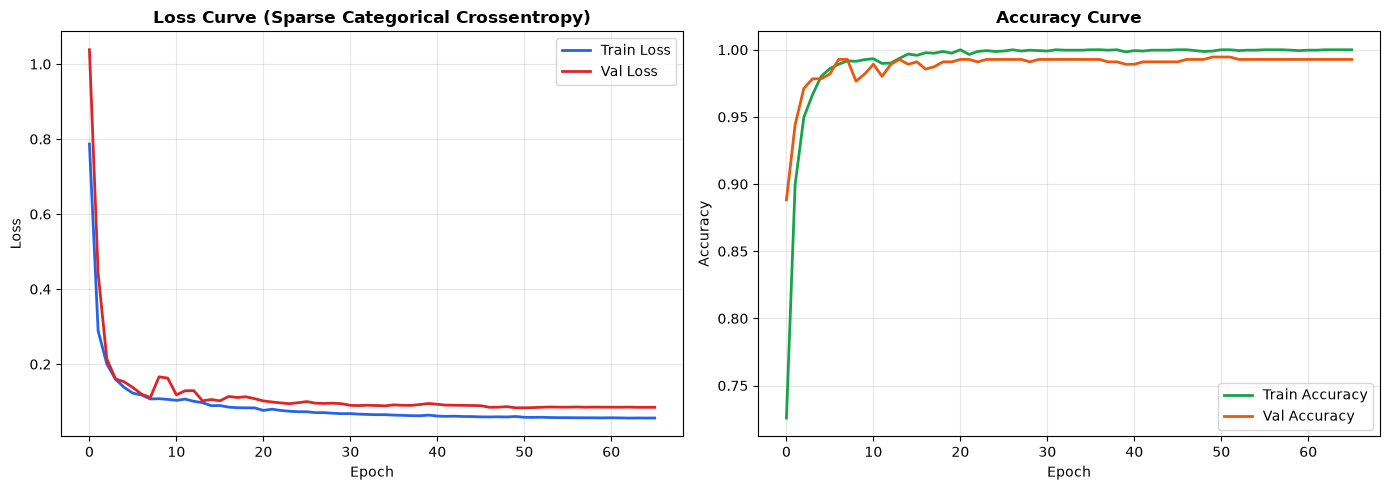

In [42]:
# Class weights computed on training subset to handle class imbalance.
class_counts = np.bincount(y_tr, minlength=n_classes)
class_weights = {
    int(i): float(len(y_tr) / (n_classes * count))
    for i, count in enumerate(class_counts) if count > 0
}

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    ),
]

history = dnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

# Softmax is used directly for inference probabilities.
dnn_probabilities = dnn_model.predict(X_test, batch_size=32, verbose=0)
dnn_predictions = np.argmax(dnn_probabilities, axis=1)
dnn_confidence = dnn_probabilities.max(axis=1)

dnn_accuracy = accuracy_score(y_test, dnn_predictions)
dnn_precision, dnn_recall, dnn_f1, _ = precision_recall_fscore_support(
    y_test, dnn_predictions, average='weighted', zero_division=0
)

print('\n' + '=' * 110)
print('DEEP NEURAL NETWORK: BGE + patterns + column-name evidence + PK/FK metadata')
print('=' * 110)
print(f'Accuracy          : {dnn_accuracy * 100:.2f}%')
print(f'Precision         : {dnn_precision * 100:.2f}%')
print(f'Recall            : {dnn_recall * 100:.2f}%')
print(f'F1                : {dnn_f1 * 100:.2f}%')
print(f'Average confidence: {dnn_confidence.mean() * 100:.2f}%')

print('\nClassification report:')
print(classification_report(
    y_test, dnn_predictions,
    labels=np.arange(n_classes),
    target_names=label_encoder.classes_, zero_division=0
))

# Plot training & validation loss and accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#2563eb', lw=2)
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#dc2626', lw=2)
axes[0].set_title('Loss Curve (Sparse Categorical Crossentropy)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#16a34a', lw=2)
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#ea580c', lw=2)
axes[1].set_title('Accuracy Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. DNN evaluation and prediction table

The prediction probabilities below come directly from the final Softmax layer. No sigmoid, thresholded binary output, or separate output activation is used.

In [43]:
actual_labels = label_encoder.inverse_transform(y_test)
predicted_labels = label_encoder.inverse_transform(dnn_predictions)

prediction_output = df.iloc[test_idx][[
    'domain','table_name','table_type','column_name','data_type','label'
]].reset_index(drop=True).copy()
prediction_output['predicted_label'] = predicted_labels
prediction_output['confidence'] = dnn_confidence
prediction_output['correct'] = prediction_output['label'] == prediction_output['predicted_label']

display(prediction_output.sort_values(['correct','confidence']).style.format({
    'confidence': '{:.2%}'
}))

cm = confusion_matrix(y_test, dnn_predictions, labels=np.arange(n_classes))
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
display(cm_df)


,domain,table_name,table_type,column_name,data_type,label,predicted_label,confidence,correct
460,Medical,dim_patient,DIMENSION,allergy,character varying,HEALTH_INFORMATION,DEMOGRAPHIC_INFORMATION,48.72%,False
591,Medical,medical,TRANSIENT,allergy,character varying,HEALTH_INFORMATION,DEMOGRAPHIC_INFORMATION,50.01%,False
232,Banking,customer_account,TRANSACTION,bank_acct_no,character varying,BANK_ACCOUNT_NUMBER,MEDICAL_RECORD_NUMBER,100.00%,False
424,Finance,financial_records,DIMENSION,bank_acct_no,character varying,BANK_ACCOUNT_NUMBER,MEDICAL_RECORD_NUMBER,100.00%,False
465,Medical,patient_record,TRANSIENT,last_name,character varying,PERSON_NAME,PERSON_NAME,50.68%,True
633,Medical,patient_record,TRANSIENT,diagnosis,character varying,HEALTH_INFORMATION,HEALTH_INFORMATION,61.28%,True
585,Medical,medical,TRANSIENT,admission_date,date,NON_PII,NON_PII,71.75%,True
374,Marketing,customer_campaign,TRANSIENT,education_level,character varying,DEMOGRAPHIC_INFORMATION,DEMOGRAPHIC_INFORMATION,83.71%,True
496,Education,education,TRANSIENT,enrollment_date,date,NON_PII,NON_PII,89.33%,True
147,Medical,fact_admission,FACT,admission_date,date,NON_PII,NON_PII,92.80%,True


,ADDRESS,BANK_ACCOUNT_NUMBER,DATE_OF_BIRTH,DEMOGRAPHIC_INFORMATION,DIRECT_IDENTIFIER,EMAIL,FINANCIAL_INFORMATION,HEALTH_INFORMATION,LOCATION,MEDICAL_RECORD_NUMBER,NON_PII,PERSON_NAME,PHONE
ADDRESS,60,0,0,0,0,0,0,0,0,0,0,0,0
BANK_ACCOUNT_NUMBER,0,43,0,0,0,0,0,0,0,2,0,0,0
DATE_OF_BIRTH,0,0,47,0,0,0,0,0,0,0,0,0,0
DEMOGRAPHIC_INFORMATION,0,0,0,54,0,0,0,0,0,0,0,0,0
DIRECT_IDENTIFIER,0,0,0,0,79,0,0,0,0,0,0,0,0
EMAIL,0,0,0,0,0,54,0,0,0,0,0,0,0
FINANCIAL_INFORMATION,0,0,0,0,0,0,73,0,0,0,0,0,0
HEALTH_INFORMATION,0,0,0,2,0,0,0,51,0,0,0,0,0
LOCATION,0,0,0,0,0,0,0,0,68,0,0,0,0
MEDICAL_RECORD_NUMBER,0,0,0,0,0,0,0,0,0,40,0,0,0


In [44]:
results = pd.DataFrame([{
    'Approach': 'DNN + BGE + patterns + column-name evidence + metadata',
    'Accuracy': dnn_accuracy,
    'Precision': dnn_precision,
    'Recall': dnn_recall,
    'F1': dnn_f1,
    'Avg Confidence': dnn_confidence.mean(),
}])
display(results.style.format({
    'Accuracy': '{:.2%}', 'Precision': '{:.2%}', 'Recall': '{:.2%}',
    'F1': '{:.2%}', 'Avg Confidence': '{:.2%}'
}))

output_path = DATASET_PATH.parent / 'dnn_softmax_pii_predictions.csv'
prediction_output.to_csv(output_path, index=False)
print('Predictions saved to:', output_path)


,Approach,Accuracy,Precision,Recall,F1,Avg Confidence
0,DNN + BGE + patterns + column-name evidence + metadata,99.57%,99.59%,99.57%,99.57%,99.70%


Predictions saved to: /home/immortalzz/cogniPII/PII-Detection-Data-Masking/ml/dataset/dnn_softmax_pii_predictions.csv


## 11. Fit the final DNN production model on ALL labeled data and export it

The evaluation split above remains untouched for reporting. The final production model is then retrained on all labeled rows using the same feature pipeline.

In [45]:
final_extra_scaler = StandardScaler()
extra_all_scaled = final_extra_scaler.fit_transform(extra_features).astype(np.float32)
X_final = np.hstack([embeddings, extra_all_scaled]).astype(np.float32)

final_dnn = build_dnn(X_final.shape[1], n_classes)
final_dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

final_class_counts = np.bincount(y, minlength=n_classes)
final_class_weights = {
    int(i): float(len(y) / (n_classes * count))
    for i, count in enumerate(final_class_counts) if count > 0
}

final_callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', patience=12, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=4, min_lr=1e-6),
]

final_dnn.fit(
    X_final, y,
    epochs=150,
    batch_size=32,
    class_weight=final_class_weights,
    callbacks=final_callbacks,
    verbose=1,
)

print('Final training rows:', len(df))
print('Final feature dimension:', X_final.shape[1])


Epoch 1/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7744 - loss: 0.6582 - learning_rate: 0.0010
Epoch 2/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9348 - loss: 0.2349 - learning_rate: 0.0010
Epoch 3/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9608 - loss: 0.1759 - learning_rate: 0.0010
Epoch 4/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9805 - loss: 0.1467 - learning_rate: 0.0010
Epoch 5/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9820 - loss: 0.1338 - learning_rate: 0.0010
Epoch 6/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9872 - loss: 0.1197 - learning_rate: 0.0010
Epoch 7/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9900 - loss: 0.1138 - learning_rate: 0.0010
Epoch 8/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9870 - loss: 0.1246 - learning_rate: 0.0010
Epoch 9/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9896 - loss: 0.1129 - learning_rate: 0.0010
E

In [46]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save the DNN architecture + learned weights in native Keras format.
final_dnn.save(MODEL_DIR / 'pii_dnn_softmax.keras')

# 2. Save a scikit-learn compatible classifier.joblib.
# This ensures existing ETL scripts (like populate_gold.py) run without any missing-file errors.
fallback_classifier = LogisticRegression(
    C=1.0, max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE
)
fallback_classifier.fit(X_final, y)
joblib.dump(fallback_classifier, MODEL_DIR / 'classifier.joblib')

# 3. Save preprocessing and label mapping.
joblib.dump(label_encoder, MODEL_DIR / 'label_encoder.joblib')
joblib.dump(final_extra_scaler, MODEL_DIR / 'extra_scaler.joblib')

# 4. Save the exact BGE model used for inference.
bge.save(str(MODEL_DIR / 'embedding_model'))

metadata = {
    'model_name': 'pii-dnn-softmax',
    'model_file': 'pii_dnn_softmax.keras',
    'fallback_classifier_file': 'classifier.joblib',
    'framework': 'tensorflow.keras',
    'version': '2.0.0',
    'architecture': 'Dense(512,relu,L2)->BN->Dropout->Dense(256,relu,L2)->BN->Dropout->Dense(128,relu,L2)->Dense(classes,softmax)',
    'output_activation': 'softmax',
    'embedding_model': MODEL_NAME,
    'embedding_dimension': int(embeddings.shape[1]),
    'pattern_feature_count': int(pattern_features.shape[1]),
    'column_name_feature_count': int(column_name_features_matrix.shape[1]),
    'metadata_feature_count': int(metadata_features.shape[1]),
    'extra_feature_dimension': int(extra_features.shape[1]),
    'total_feature_dimension': int(X_final.shape[1]),
    'classes': label_encoder.classes_.tolist(),
    'column_name_keywords': COLUMN_KEYWORDS,
    'pattern_feature_names': pattern_feature_names,
    'extra_feature_names': extra_feature_names,
    'training_rows': int(len(df)),
    'training_classes': int(n_classes),
    'random_state': RANDOM_STATE,
    'inference_rule': 'argmax(softmax probabilities)',
}

(MODEL_DIR / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Production model exported to:', MODEL_DIR.resolve())
print('\nBundle contents:')
for path in sorted(MODEL_DIR.rglob('*')):
    if path.is_file():
        print(' ', path.relative_to(MODEL_DIR))


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.47it/s]

Production model exported to: /home/immortalzz/cogniPII/PII-Detection-Data-Masking/ml/pii_classifier

Bundle contents:
  classifier.joblib
  embedding_model/1_Pooling/config.json
  embedding_model/2_Normalize/config.json
  embedding_model/README.md
  embedding_model/config.json
  embedding_model/config_sentence_transformers.json
  embedding_model/model.safetensors
  embedding_model/modules.json
  embedding_model/sentence_bert_config.json
  embedding_model/tokenizer.json
  embedding_model/tokenizer_config.json
  extra_scaler.joblib
  label_encoder.joblib
  metadata.json
  pii_dnn_softmax.keras
